In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import csv
from scipy import spatial
from sko.PSO import PSO, PSO_TSP

# 1. SETUP & DATA LOADING (berlin52)
def ReadTsp(fn):
    cities = []
    with open(fn + ".tsp", "rt") as f:
        reader = csv.reader(f, delimiter=" ", skipinitialspace=True)
        coordinates = False
        for row in reader:
            if not row or row[0] == "EOF": break
            if coordinates: cities.append((float(row[1]), float(row[2])))
            elif row[0] == "NODE_COORD_SECTION": coordinates = True
    return np.array(cities)

points_coordinate = ReadTsp('berlin52')
num_points = len(points_coordinate)
optimal_val = 7542

# Distance Matrix (Rounded for TSPLIB standard)
dist_matrix = spatial.distance.cdist(points_coordinate, points_coordinate, metric='euclidean')
dist_matrix = np.rint(dist_matrix).astype(int)

def cal_total_distance(routine):
    num_cities = len(routine)
    return sum([dist_matrix[routine[i % num_cities], routine[(i + 1) % num_cities]] for i in range(num_cities)])

# 2. TEACHER'S ROV OBJECTIVE FUNCTION
def rov_objective(p):
    # Map continuous values to discrete route using argsort
    route = np.argsort(p)
    return cal_total_distance(route)

# 3. EXPERIMENTATION FUNCTION (Monte Carlo + Parameters)
def run_experiment(algo_type, pop, iters, w, c1, c2, rounds=10):
    runtimes = []
    fitness_results = []
    
    for _ in range(rounds):
        start = time.time()
        if algo_type == 'Discrete':
            model = PSO_TSP(func=cal_total_distance, n_dim=num_points, size_pop=pop, max_iter=iters, w=w, c1=c1, c2=c2)
        else: # ROV / Teacher Approach
            model = PSO(func=rov_objective, n_dim=num_points, pop=pop, max_iter=iters, lb=[0]*num_points, ub=[100]*num_points, w=w, c1=c1, c2=c2)
        
        best_x, best_y = model.run()
        runtimes.append(time.time() - start)
        fitness_results.append(best_y[0])
        
    return {
        'avg_fit': np.mean(fitness_results),
        'std_fit': np.std(fitness_results),
        'min_fit': np.min(fitness_results),
        'avg_time': np.mean(runtimes),
        'gap': ((np.min(fitness_results) - optimal_val) / optimal_val) * 100
    }

In [10]:
# Configurations to test (Varying complexity vs parameters)
configs = [
    {'type': 'Discrete', 'pop': 50,  'iter': 200, 'w': 0.8, 'c1': 1.5, 'c2': 1.5}, # Balanced
    {'type': 'Discrete', 'pop': 100, 'iter': 500, 'w': 0.9, 'c1': 1.0, 'c2': 1.0}, # High effort
    {'type': 'ROV',      'pop': 50,  'iter': 200, 'w': 0.6, 'c1': 0.5, 'c2': 0.5}, # Minimal convergence
    {'type': 'ROV',      'pop': 100, 'iter': 500, 'w': 0.8, 'c1': 1.5, 'c2': 1.5}, # Teacher-style
    {'type': 'ROV',      'pop': 30,  'iter': 100, 'w': 0.9, 'c1': 2.0, 'c2': 1.5}  # Fast/Risky
]

all_results = []
for conf in configs:
    res = run_experiment(conf['type'], conf['pop'], conf['iter'], conf['w'], conf['c1'], conf['c2'])
    res.update(conf)
    all_results.append(res)

df = pd.DataFrame(all_results)
print(df[['type', 'pop', 'iter', 'avg_fit', 'std_fit', 'avg_time', 'gap']])

       type  pop  iter  avg_fit      std_fit  avg_time         gap
0  Discrete   50   200  10645.1   358.630297  0.653425   33.505701
1  Discrete  100   500   8563.7   359.826639  3.267804    6.337841
2       ROV   50   200  20261.1  1547.630088  0.145067  147.387961
3       ROV  100   500  16726.7  1305.782451  0.689262   83.518960
4       ROV   30   100  20066.7   778.193941  0.043494  143.715195


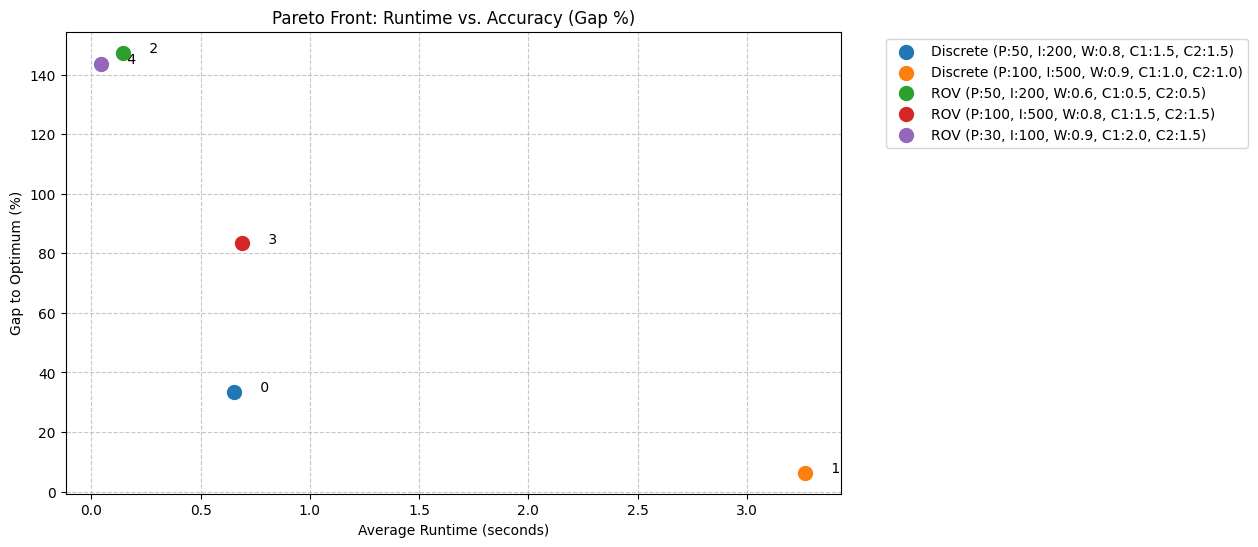

In [13]:
plt.figure(figsize=(10, 6))
for i, row in df.iterrows():
    label = f"{row['type']} (P:{row['pop']}, I:{row['iter']}, W:{row['w']}, C1:{row['c1']}, C2:{row['c2']})"
    plt.scatter(row['avg_time'], row['gap'], s=100, label=label)
    plt.text(row['avg_time']+0.1, row['gap'], f" {i}")

plt.title("Pareto Front: Runtime vs. Accuracy (Gap %)")
plt.xlabel("Average Runtime (seconds)")
plt.ylabel("Gap to Optimum (%)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from itertools import product
from sko.PSO import PSO, PSO_TSP
from scipy import spatial

def cal_total_distance(routine):
    num_cities = len(routine)
    return sum([dist_matrix[routine[i % num_cities], routine[(i + 1) % num_cities]] for i in range(num_cities)])

def rov_objective(p):
    return cal_total_distance(np.argsort(p))

optimal_val = 7542
num_points = 52

pops = [50, 100]
iters = [200, 500]
ws = [0.6, 0.9]
c_sums = [1.5, 3.5]

results_list = []

print("Starting Parameter Sweep...")

for algo in ['Discrete', 'ROV']:
    for p, i, w, c_sum in product(pops, iters, ws, c_sums):
        
        c1 = c2 = c_sum / 2
        
        if not (1 > w > 0.5 and (c1 + c2) >= 1 and (c1 + c2) < 4):
            continue
            
        runtimes = []
        fitness_scores = []
        rounds = 5
        
        for _ in range(rounds):
            start = time.time()
            if algo == 'Discrete':
                model = PSO_TSP(func=cal_total_distance, n_dim=num_points, size_pop=p, max_iter=i, w=w, c1=c1, c2=c2)
            else:
                model = PSO(func=rov_objective, n_dim=num_points, pop=p, max_iter=i, lb=[0]*num_points, ub=[100]*num_points, w=w, c1=c1, c2=c2)
            
            _, best_y = model.run()
            runtimes.append(time.time() - start)
            fitness_scores.append(best_y[0])
            
        avg_fit = np.mean(fitness_scores)
        gap = ((np.min(fitness_scores) - optimal_val) / optimal_val) * 100
        avg_time = np.mean(runtimes)
        
        results_list.append({
            'Algo': algo, 'Pop': p, 'Iter': i, 'w': w, 'c_sum': c_sum,
            'Avg_Fit': avg_fit, 'Std_Dev': np.std(fitness_scores),
            'Avg_Time': avg_time, 'Gap': gap
        })
        print(f"Finished: {algo} | Pop:{p} w:{w} c:{c_sum} -> Gap: {gap:.2f}%")

df_results = pd.DataFrame(results_list)


Starting Parameter Sweep...
Finished: Discrete | Pop:50 w:0.6 c:1.5 -> Gap: 33.90%
Finished: Discrete | Pop:50 w:0.6 c:3.5 -> Gap: 31.80%
Finished: Discrete | Pop:50 w:0.9 c:1.5 -> Gap: 30.89%
Finished: Discrete | Pop:50 w:0.9 c:3.5 -> Gap: 33.93%
Finished: Discrete | Pop:50 w:0.6 c:1.5 -> Gap: 9.64%
Finished: Discrete | Pop:50 w:0.6 c:3.5 -> Gap: 16.44%
Finished: Discrete | Pop:50 w:0.9 c:1.5 -> Gap: 15.39%
Finished: Discrete | Pop:50 w:0.9 c:3.5 -> Gap: 14.13%
Finished: Discrete | Pop:100 w:0.6 c:1.5 -> Gap: 20.30%
Finished: Discrete | Pop:100 w:0.6 c:3.5 -> Gap: 20.27%
Finished: Discrete | Pop:100 w:0.9 c:1.5 -> Gap: 20.71%
Finished: Discrete | Pop:100 w:0.9 c:3.5 -> Gap: 28.52%
Finished: Discrete | Pop:100 w:0.6 c:1.5 -> Gap: 10.06%
Finished: Discrete | Pop:100 w:0.6 c:3.5 -> Gap: 13.01%
Finished: Discrete | Pop:100 w:0.9 c:1.5 -> Gap: 11.15%
Finished: Discrete | Pop:100 w:0.9 c:3.5 -> Gap: 9.96%
Finished: ROV | Pop:50 w:0.6 c:1.5 -> Gap: 122.01%
Finished: ROV | Pop:50 w:0.6 c:3.5 

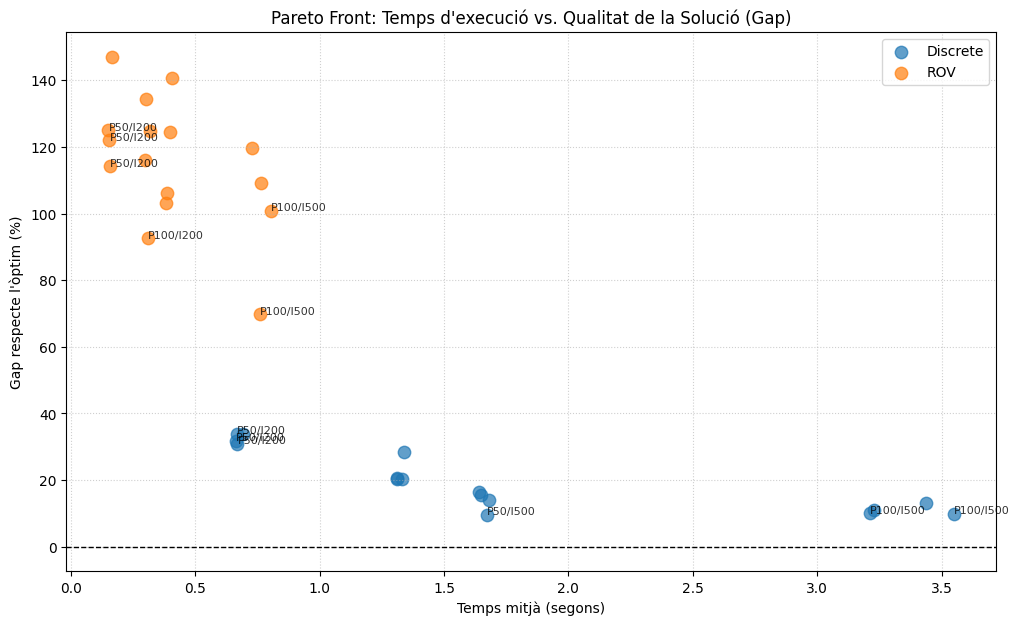

In [15]:
plt.figure(figsize=(12, 7))

# Separem per algoritme per veure millor la comparativa
for algo in df_results['Algo'].unique():
    subset = df_results[df_results['Algo'] == algo]
    plt.scatter(subset['Avg_Time'], subset['Gap'], label=algo, s=80, alpha=0.7)
    
    # Posem etiquetes a alguns punts clau per a la teva argumentació
    for idx, row in subset.iterrows():
        if row['Gap'] < subset['Gap'].quantile(0.2) or row['Avg_Time'] < subset['Avg_Time'].quantile(0.2):
            plt.annotate(f"P{int(row['Pop'])}/I{int(row['Iter'])}", 
                         (row['Avg_Time'], row['Gap']), fontsize=8, alpha=0.8)

plt.axhline(0, color='black', linestyle='--', linewidth=1) # Línia de l'òptim real
plt.title("Pareto Front: Temps d'execució vs. Qualitat de la Solució (Gap)")
plt.xlabel("Temps mitjà (segons)")
plt.ylabel("Gap respecte l'òptim (%)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [20]:
# Parameters to test
filename = 'berlin52'


pop_sizes = [50, 100, 200]
max_iter = 2000
results_pso = []


print(f"Starting PSO experiments on {filename}...")
for pop in pop_sizes:
    res = run_experiment('ROV', pop, max_iter,0.8, 1.5, 1.5)
    res['type'] = 'ROV'
    res['pop'] = pop
    res['iter'] = max_iter
    results_pso.append(res)
    

df = pd.DataFrame(results_pso)
print(df[['type', 'pop', 'iter', 'avg_fit', 'min_fit', 'std_fit', 'avg_time', 'gap']])


Starting PSO experiments on berlin52...
  type  pop  iter  avg_fit  min_fit      std_fit  avg_time        gap
0  ROV   50  2000  17338.5  14396.0  1749.096352  1.412751  90.877751
1  ROV  100  2000  17164.0  13617.0  1501.265599  2.794595  80.548926
2  ROV  200  2000  16640.8  13506.0  1338.229711  5.461028  79.077168


In [ ]:
res = run_experiment('ROV', conf['pop'], conf['iter'], conf['w'], conf['c1'], conf['c2'])
all_results.append(res)

df = pd.DataFrame(all_results)
print(df[['type', 'pop', 'iter', 'avg_fit', 'std_fit', 'avg_time', 'gap']])

In [ ]:
# Configuració bàsica
dimensions = 10
lower_bound = [-600] * dimensions # Límits típics per Griewank
upper_bound = [600] * dimensions
rounds_sweep = 30
def_pop = 50
def_iter = 150

results_pso = []
master_results = {}

print(f"Initializing Parameter Sweep - Griewank {dimensions}D...")

# Escombrat de Inèrcia (w) i Factors (c1, c2)
# Ens assegurem de complir Engelbrecht: c1 + c2 <= 4
configs = [
    {'w': 0.8, 'c1': 0.5, 'c2': 0.5}, # Exploració moderada
    {'w': 0.9, 'c1': 1.5, 'c2': 1.5}, # Exploració alta (c1+c2 = 3)
    {'w': 0.4, 'c1': 2.0, 'c2': 2.0}, # Convergència ràpida (c1+c2 = 4)
    {'w': 0.9, 'c1': 0.1, 'c2': 3.9}  # Molt social, poc cognitiu (c1+c2 = 4)
]

for cfg in configs:
    w, c1, c2 = cfg['w'], cfg['c1'], cfg['c2']
    print(f"\nTrying PSO with these parameters -> w: {w}, c1: {c1}, c2: {c2}...")
    start = time.time()
    result = run_experiment('PSO', griewank, dimensions, lower_bound, upper_bound, cfg, rounds_sweep, def_iter, def_pop, title_suffix=f"w:{w}, c1:{c1}, c2:{c2}")
    results_pso.append({'Alg': 'PSO', 'w': w, 'c1': c1, 'c2': c2, 'Avg Fit': result['avg'], 'Min Fit': result['min'], 'Std Dev': result['std']})
    label = f"w:{w}, c1:{c1}, c2:{c2}"
    master_results[label] = result
    print(f"  -> Made in {time.time()-start:.2f}s | Avg: {result['avg']:.4f} | Min: {result['min']:.4f} | Std: {result['std']:.4f}")

df_pso = pd.DataFrame(results_pso)
print("\n" + "="*70)
print(" RESULTS PSO - GRIEWANK " + str(dimensions) + "D")
print("="*70)
print(df_pso.to_string(index=False))

plot_final_comparison(master_results, var_name="w, c1, c2", filename="comparativa_final_pso_griewank_w.png")

In [ ]:
optimal_val = 7542
def run_experiment(algo_type, pop, iters, w, c1, c2, rounds=10, title_suffix=""):
    runtimes = []
    final_results = []
    
    all_best_histories = []
    all_avg_histories = []
    
    for r in range(rounds):
        start = time.time()
        
        if algo_type == 'Discrete':
            model = PSO_TSP(func=cal_total_distance, n_dim=num_points, size_pop=pop, max_iter=iters, w=w, c1=c1, c2=c2)
        else: # ROV / Teacher Approach
            model = PSO(func=rov_objective, n_dim=num_points, pop=pop, max_iter=iters, lb=[0]*num_points, ub=[100]*num_points, w=w, c1=c1, c2=c2)
            model.record_mode = True # Necessari per capturar tota la població en PSO estàndard
        
        best_x, best_y = model.run()
        runtimes.append(time.time() - start)
        
        # Assegurem que agafem el valor correctament (de vegades és array, de vegades escalar)
        final_val = best_y[0] if isinstance(best_y, (list, np.ndarray)) else best_y
        final_results.append(final_val)
        
        # --- EXTRACCIÓ D'HISTÒRICS ---
        round_best = []
        round_avg = []
        
        if algo_type == 'ROV':
            hist_Y = model.record_value['Y']
            for fits in hist_Y:
                round_best.append(np.min(fits))
                round_avg.append(np.mean(fits))
        else:
            # PSO_TSP (Discrete) només sol guardar el millor de cada iteració
            hist_Y = model.all_history_Y
            for fits in hist_Y:
                if isinstance(fits, (list, np.ndarray)):
                    round_best.append(np.min(fits))
                    round_avg.append(np.mean(fits))
                else:
                    # Si no tenim info de tota la població, igualem best i avg per evitar errors al plot
                    round_best.append(fits)
                    round_avg.append(fits)
        
        all_best_histories.append(round_best)
        all_avg_histories.append(round_avg)

    # --- CÀLCULS FINALS ---
    avg_min_fit = np.mean(all_best_histories, axis=0)
    std_min_fit = np.std(all_best_histories, axis=0)
    avg_pop_avg = np.mean(all_avg_histories, axis=0)
    
    min_fit_all_rounds = np.min(final_results)
    gap = ((min_fit_all_rounds - optimal_val) / optimal_val) * 100
    
    # --- PLOT INDIVIDUAL DE LA CONFIGURACIÓ ---
    plt.figure(figsize=(10, 5))
    iters_arr = np.arange(len(avg_min_fit))
    
    plt.plot(iters_arr, avg_pop_avg, label='Population Average (Mean)', color='blue', linestyle='--', alpha=0.6)
    plt.plot(iters_arr, avg_min_fit, label='Best Fitness (Mean)', color='green', linewidth=2)
    plt.fill_between(iters_arr, np.maximum(avg_min_fit - std_min_fit, 1e-15), 
                     avg_min_fit + std_min_fit, color='green', alpha=0.15)
    
    plt.yscale('log')
    plt.title(f"Detailed Evolution: {algo_type}\n{title_suffix}", fontweight='bold')
    plt.xlabel('Iterations')
    plt.ylabel('Total Distance (Log Scale)')
    plt.legend()
    plt.grid(True, which="both", linestyle=':', alpha=0.5)
    plt.show()

    return {
        'avg_fit': np.mean(final_results),
        'min_fit': min_fit_all_rounds,
        'std_fit': np.std(final_results),
        'avg_time': np.mean(runtimes),
        'gap': gap,
        'hist_avg_min': avg_min_fit,
        'hist_std_min': std_min_fit,
        'hist_pop_avg': avg_pop_avg
    }

def plot_final_comparison(results_master, var_name, filename):
    """Genera un gràfic comparant el Millor Fitness i el Fitness Mitjà de la població."""
    plt.figure(figsize=(12, 8))
    
    # Utilitzem una paleta de colors bonica
    colors = plt.cm.get_cmap('tab10', len(results_master))
    
    for i, (val, res) in enumerate(results_master.items()):
        iters = np.arange(len(res['hist_avg_min']))
        c = colors(i)
        
        # 1. Plot del Millor Fitness (Línia sòlida)
        plt.plot(iters, res['hist_avg_min'], 
                 label=f'{var_name}={val} (Best)', 
                 color=c, linewidth=2)
        
        # 2. Plot del Fitness Mitjà de la població (Línia puntejada i més transparent)
        if 'hist_pop_avg' in res:
            plt.plot(iters, res['hist_pop_avg'], 
                     color=c, linestyle='--', alpha=0.5, linewidth=1.5,
                     label=f'{var_name}={val} (Pop Avg)')
        
        # 3. Ombra de la desviació estàndard (només per al Best per no embrutar massa)
        plt.fill_between(iters, 
                         res['hist_avg_min'] - res['hist_std_min'], 
                         res['hist_avg_min'] + res['hist_std_min'], 
                         color=c, alpha=0.1)

    plt.yscale('log')
    plt.xlabel('Iterations', fontsize=12)
    plt.ylabel('Fitness (Log Scale)', fontsize=12)
    plt.title(f'Comparative Analysis: {var_name}\nSolid = Best Fitness | Dashed = Population Average', 
              fontweight='bold', fontsize=14)
    
    # Posem la llegenda fora perquè serà llarga (ara tenim 2 línies per config)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
    
    plt.grid(True, which="both", linestyle=':', alpha=0.4)
    plt.tight_layout()
    
    if filename:
        plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

Initializing Parameter Sweep - Berlin52 TSP
Settings: Pop=100, Iter=500, Rounds=10


>>> Testing Algorithm: ROV
Running config: Standard (Balanced) (w:0.8, c1:1.0, c2:1.0)... 

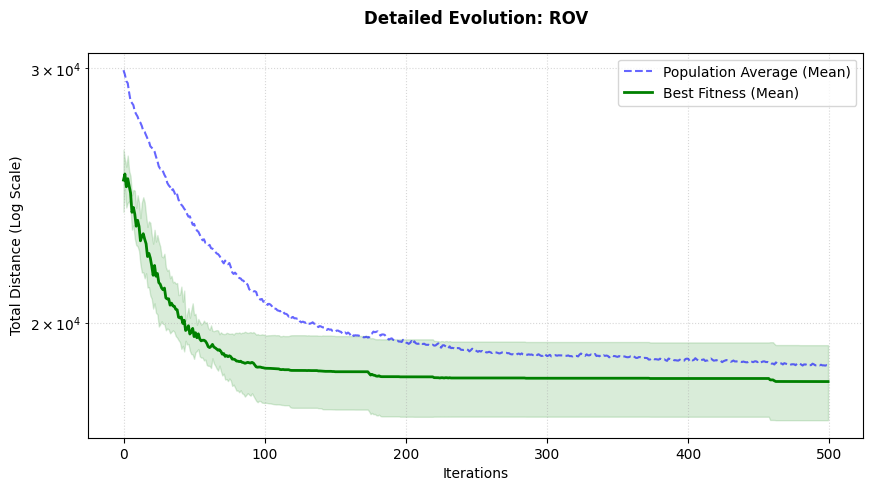

Done! | Gap: 111.96% | Time: 3.55s
Running config: High Inertia (Exploration) (w:0.9, c1:0.5, c2:0.6)... 

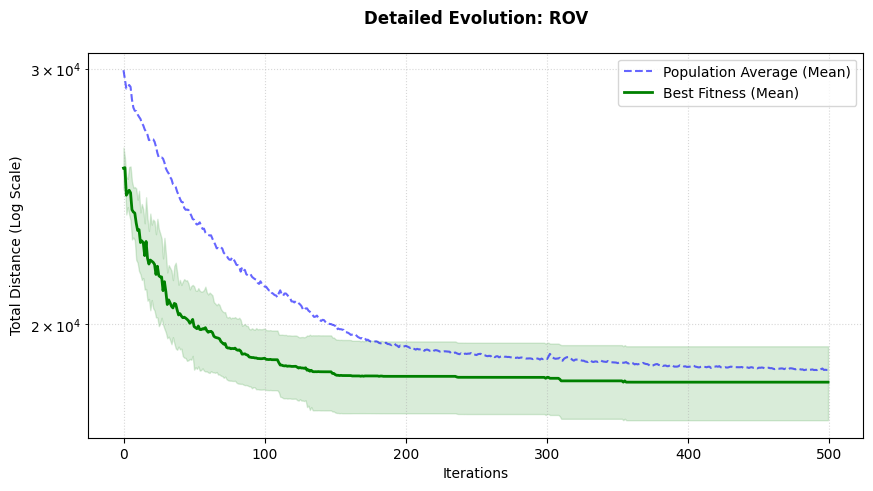

Done! | Gap: 112.52% | Time: 3.27s
Running config: High Acceleration (Convergence) (w:0.6, c1:1.8, c2:1.8)... 

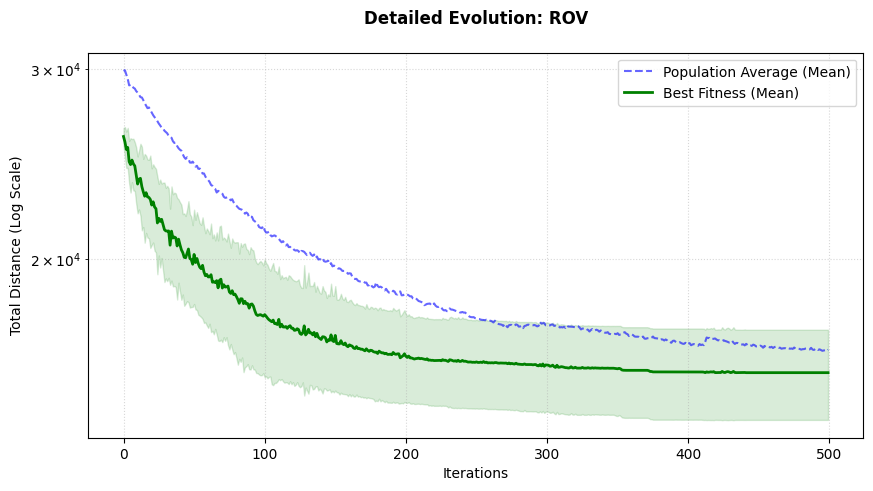

Done! | Gap: 78.73% | Time: 2.62s
Running config: Highly Social (Global Influence) (w:0.7, c1:0.5, c2:2.5)... 

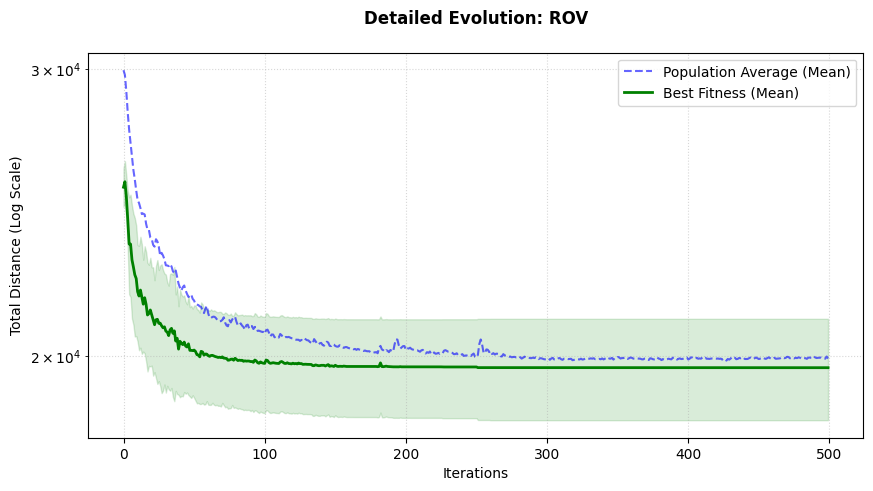

Done! | Gap: 129.55% | Time: 3.23s

                             PSO TSP COMPARATIVE RESULTS                             
Algo                           Config   w  c1  c2  Avg Fit  Min Fit  Gap %  Avg Time (s)  Std Dev
 ROV              Standard (Balanced) 0.8 1.0 1.0  18211.4  15986.0 111.96         3.555  1088.12
 ROV       High Inertia (Exploration) 0.9 0.5 0.6  18247.6  16028.0 112.52         3.269  1069.38
 ROV  High Acceleration (Convergence) 0.6 1.8 1.8  15689.5  13480.0  78.73         2.621  1505.95
 ROV Highly Social (Global Influence) 0.7 0.5 2.5  19664.1  17313.0 129.55         3.229  1408.68


In [31]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

rounds_sweep = 10
def_pop = 100
def_iter = 500

results_pso = []
master_results = {}

configs = [
    {'w': 0.8, 'c1': 1.0, 'c2': 1.0, 'desc': 'Standard (Balanced)'}, 
    {'w': 0.9, 'c1': 0.5, 'c2': 0.6, 'desc': 'High Inertia (Exploration)'},
    {'w': 0.6, 'c1': 1.8, 'c2': 1.8, 'desc': 'High Acceleration (Convergence)'},
    {'w': 0.7, 'c1': 0.5, 'c2': 2.5, 'desc': 'Highly Social (Global Influence)'}
]

print(f"Initializing Parameter Sweep - Berlin52 TSP")
print(f"Settings: Pop={def_pop}, Iter={def_iter}, Rounds={rounds_sweep}\n")

print(f"\n>>> Testing Algorithm: {'ROV'}")
for cfg in configs:
    w, c1, c2, desc = cfg['w'], cfg['c1'], cfg['c2'], cfg['desc']
    
    print(f"Running config: {desc} (w:{w}, c1:{c1}, c2:{c2})...", end=" ")
    
    start_time = time.time()
    
    result = run_experiment(algo, def_pop, def_iter, w, c1, c2, rounds=rounds_sweep)
    
    elapsed = time.time() - start_time
    
    results_pso.append({
        'Algo': algo,
        'Config': desc,
        'w': w, 'c1': c1, 'c2': c2,
        'Avg Fit': round(result['avg_fit'], 2),
        'Min Fit': round(result['min_fit'], 2),
        'Gap %': round(result['gap'], 2),
        'Avg Time (s)': round(result['avg_time'], 3),
        'Std Dev': round(result['std_fit'], 2)
    })
    
    label = f"{algo} - {desc}"
    master_results[label] = result
    
    print(f"Done! | Gap: {result['gap']:.2f}% | Time: {result['avg_time']:.2f}s")

df_pso = pd.DataFrame(results_pso)
print("\n" + "="*85)
print(f"{'PSO TSP COMPARATIVE RESULTS':^85}")
print("="*85)
print(df_pso.to_string(index=False))


C:\Users\enric\AppData\Local\Temp\ipykernel_22692\3879541567.py:89: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(results_master))


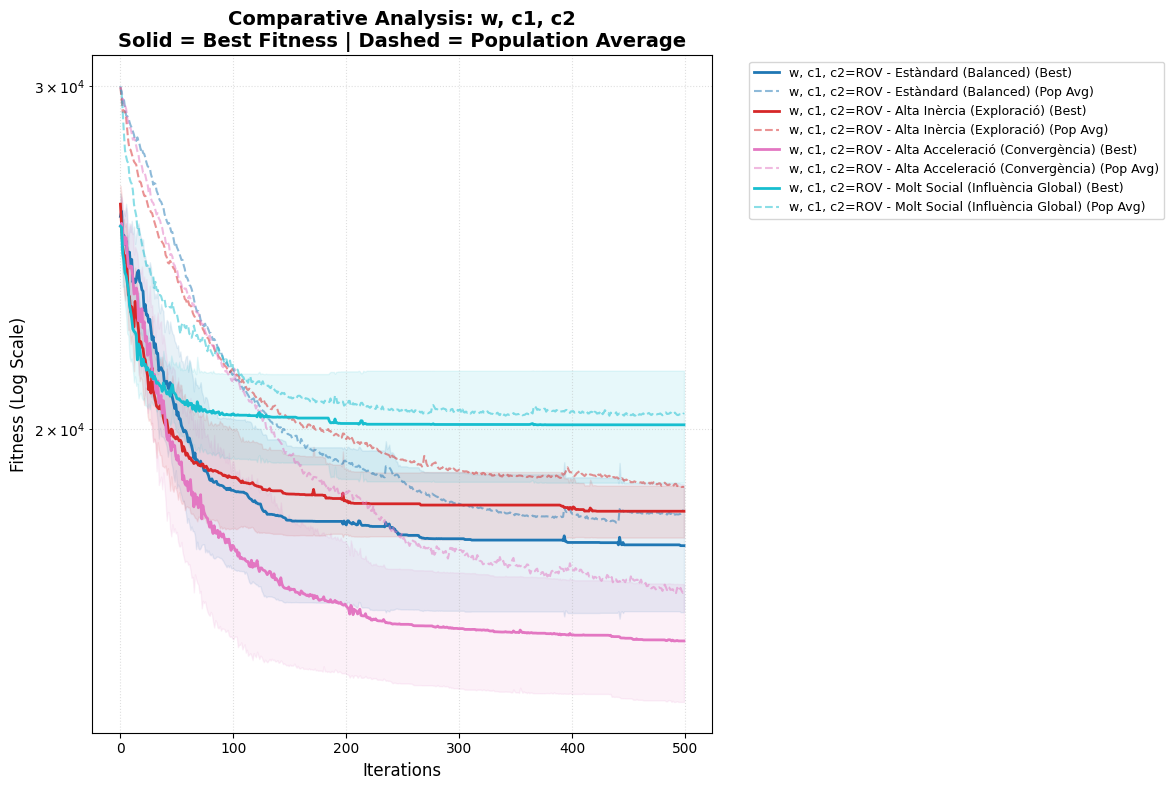

In [30]:
plot_final_comparison(master_results, var_name="w, c1, c2", filename="comparativa_pso_tsp_w.png")